In [1]:
import numpy as np
from scipy.integrate import solve_bvp
from scipy.interpolate import RBFInterpolator
import pandas as pd
import matplotlib.pyplot as plt


# Set up w and dw for variable current

In [2]:
def rbf_gradient(interp, x):
    x = np.atleast_2d(x)
    x_norm = (x - interp._shift) / interp._scale
    y_norm = (interp.y - interp._shift) / interp._scale
    coeffs = interp._coeffs.ravel()

    diff = x_norm[:, None, :] - y_norm[None, :, :]     # (M, N, d) normalized
    r    = np.sqrt(np.sum(diff**2, axis=-1))            # (M, N)

    with np.errstate(divide='ignore', invalid='ignore'):
        factor = np.where(r == 0.0, 0.0, 2 * np.log(np.where(r == 0, 1, r)) + 1)

    kernel_grad = factor[:, :, None] * diff             # (M, N, d) w.r.t. x_norm
    grad = np.einsum('mnd,n->md', kernel_grad, coeffs[:len(y_norm)])

    poly_coeffs = coeffs[len(y_norm):]
    # divide EVERYTHING by scale (chain rule through normalization)
    return (grad + poly_coeffs[1:]) / interp._scale     # (M, d)

In [3]:
all_data = pd.read_csv('data/green_bay_wind_snapshot.csv')

X, Y, theta, speed = all_data['lon'], all_data['lat'], np.deg2rad(all_data['waveMeanDirection'].to_numpy()), 1 / all_data['waveTp'].to_numpy()

u, v = speed * np.sin(theta), speed * np.cos(theta)

# coordinates
y = np.column_stack([X, Y])

u_interp = RBFInterpolator(y, u, kernel="thin_plate_spline", smoothing=0.0)
v_interp = RBFInterpolator(y, v, kernel="thin_plate_spline", smoothing=0.0)

In [4]:
def w(s):
    return np.vstack([u_interp(s), v_interp(s)])

def dw(s):
    grad_u = rbf_gradient(u_interp, s)
    grad_v = rbf_gradient(v_interp, s)
    return np.array([grad_u.T, grad_v.T])

def ode(t, Y, p):
    v = 10
    T = p[0]
    x, y, l1, l2 = Y
    lnorm = np.sqrt(l1**2 + l2**2) + 1e-10

    u1 = v * l1 / lnorm
    u2 = v * l2 / lnorm

    s = np.column_stack([x, y]) 
    w1, w2 = w(s)
  
    dx = T * (u1 + w1)
    dy = T * (u2 + w2)

    Dw = dw(s)                  # (2, 2, n)
    lam = np.array([l1, l2])    # (2, n)

    # This line computes -T * Dw.T @ [l1, l2] for each of n points
    # Dw is (2, 2, n) and lam is (2, n)
    # So the jin,jn->in means that output_{i, n} = sum_j{Dw_{j, i, n} * lam_{j,n}}
    dl1, dl2 = -T * np.einsum('jin,jn->in', Dw, lam)

    return np.array([dx, dy, dl1, dl2])

def solve(x0, xf):

    def bc(ya, yb, p):
        T = p[0]
        v=10

        xa, ya, l1a, l2a = ya
        xb, yb, l1b, l2b = yb

        lam_norm = np.sqrt(l1b**2 + l2b**2) + 1e-10
        u1b = v * l1b / lam_norm
        u2b = v * l2b / lam_norm

        sb = np.array([xb, yb])[None, :]
        wb = w(sb).squeeze(1)
        
        Hf = l1b * (u1b + wb[0]) + l2b * (u2b + wb[1]) - 1.0

        return np.array([
            xa - x0[0],
            ya - x0[1],
            xb - xf[0],
            yb - xf[1],
            Hf
        ])

    t = np.linspace(0, 1, 100)

    # initial guess
    Y_guess = np.zeros((4, t.size))
    Y_guess[0] = np.linspace(x0[0], xf[0], t.size)
    Y_guess[1] = np.linspace(x0[1], xf[1], t.size)
    Y_guess[2] = 1.0
    Y_guess[3] = 1.0

    p_guess = np.array([2.0])

    sol = solve_bvp(ode, bc, t, Y_guess, p=p_guess)

    return sol

In [5]:
x0 = np.array([-87.375, 45.20])     # Chambers Island
xf = np.array([-87.614, 45.108])    # Finish

sol = solve(x0, xf)

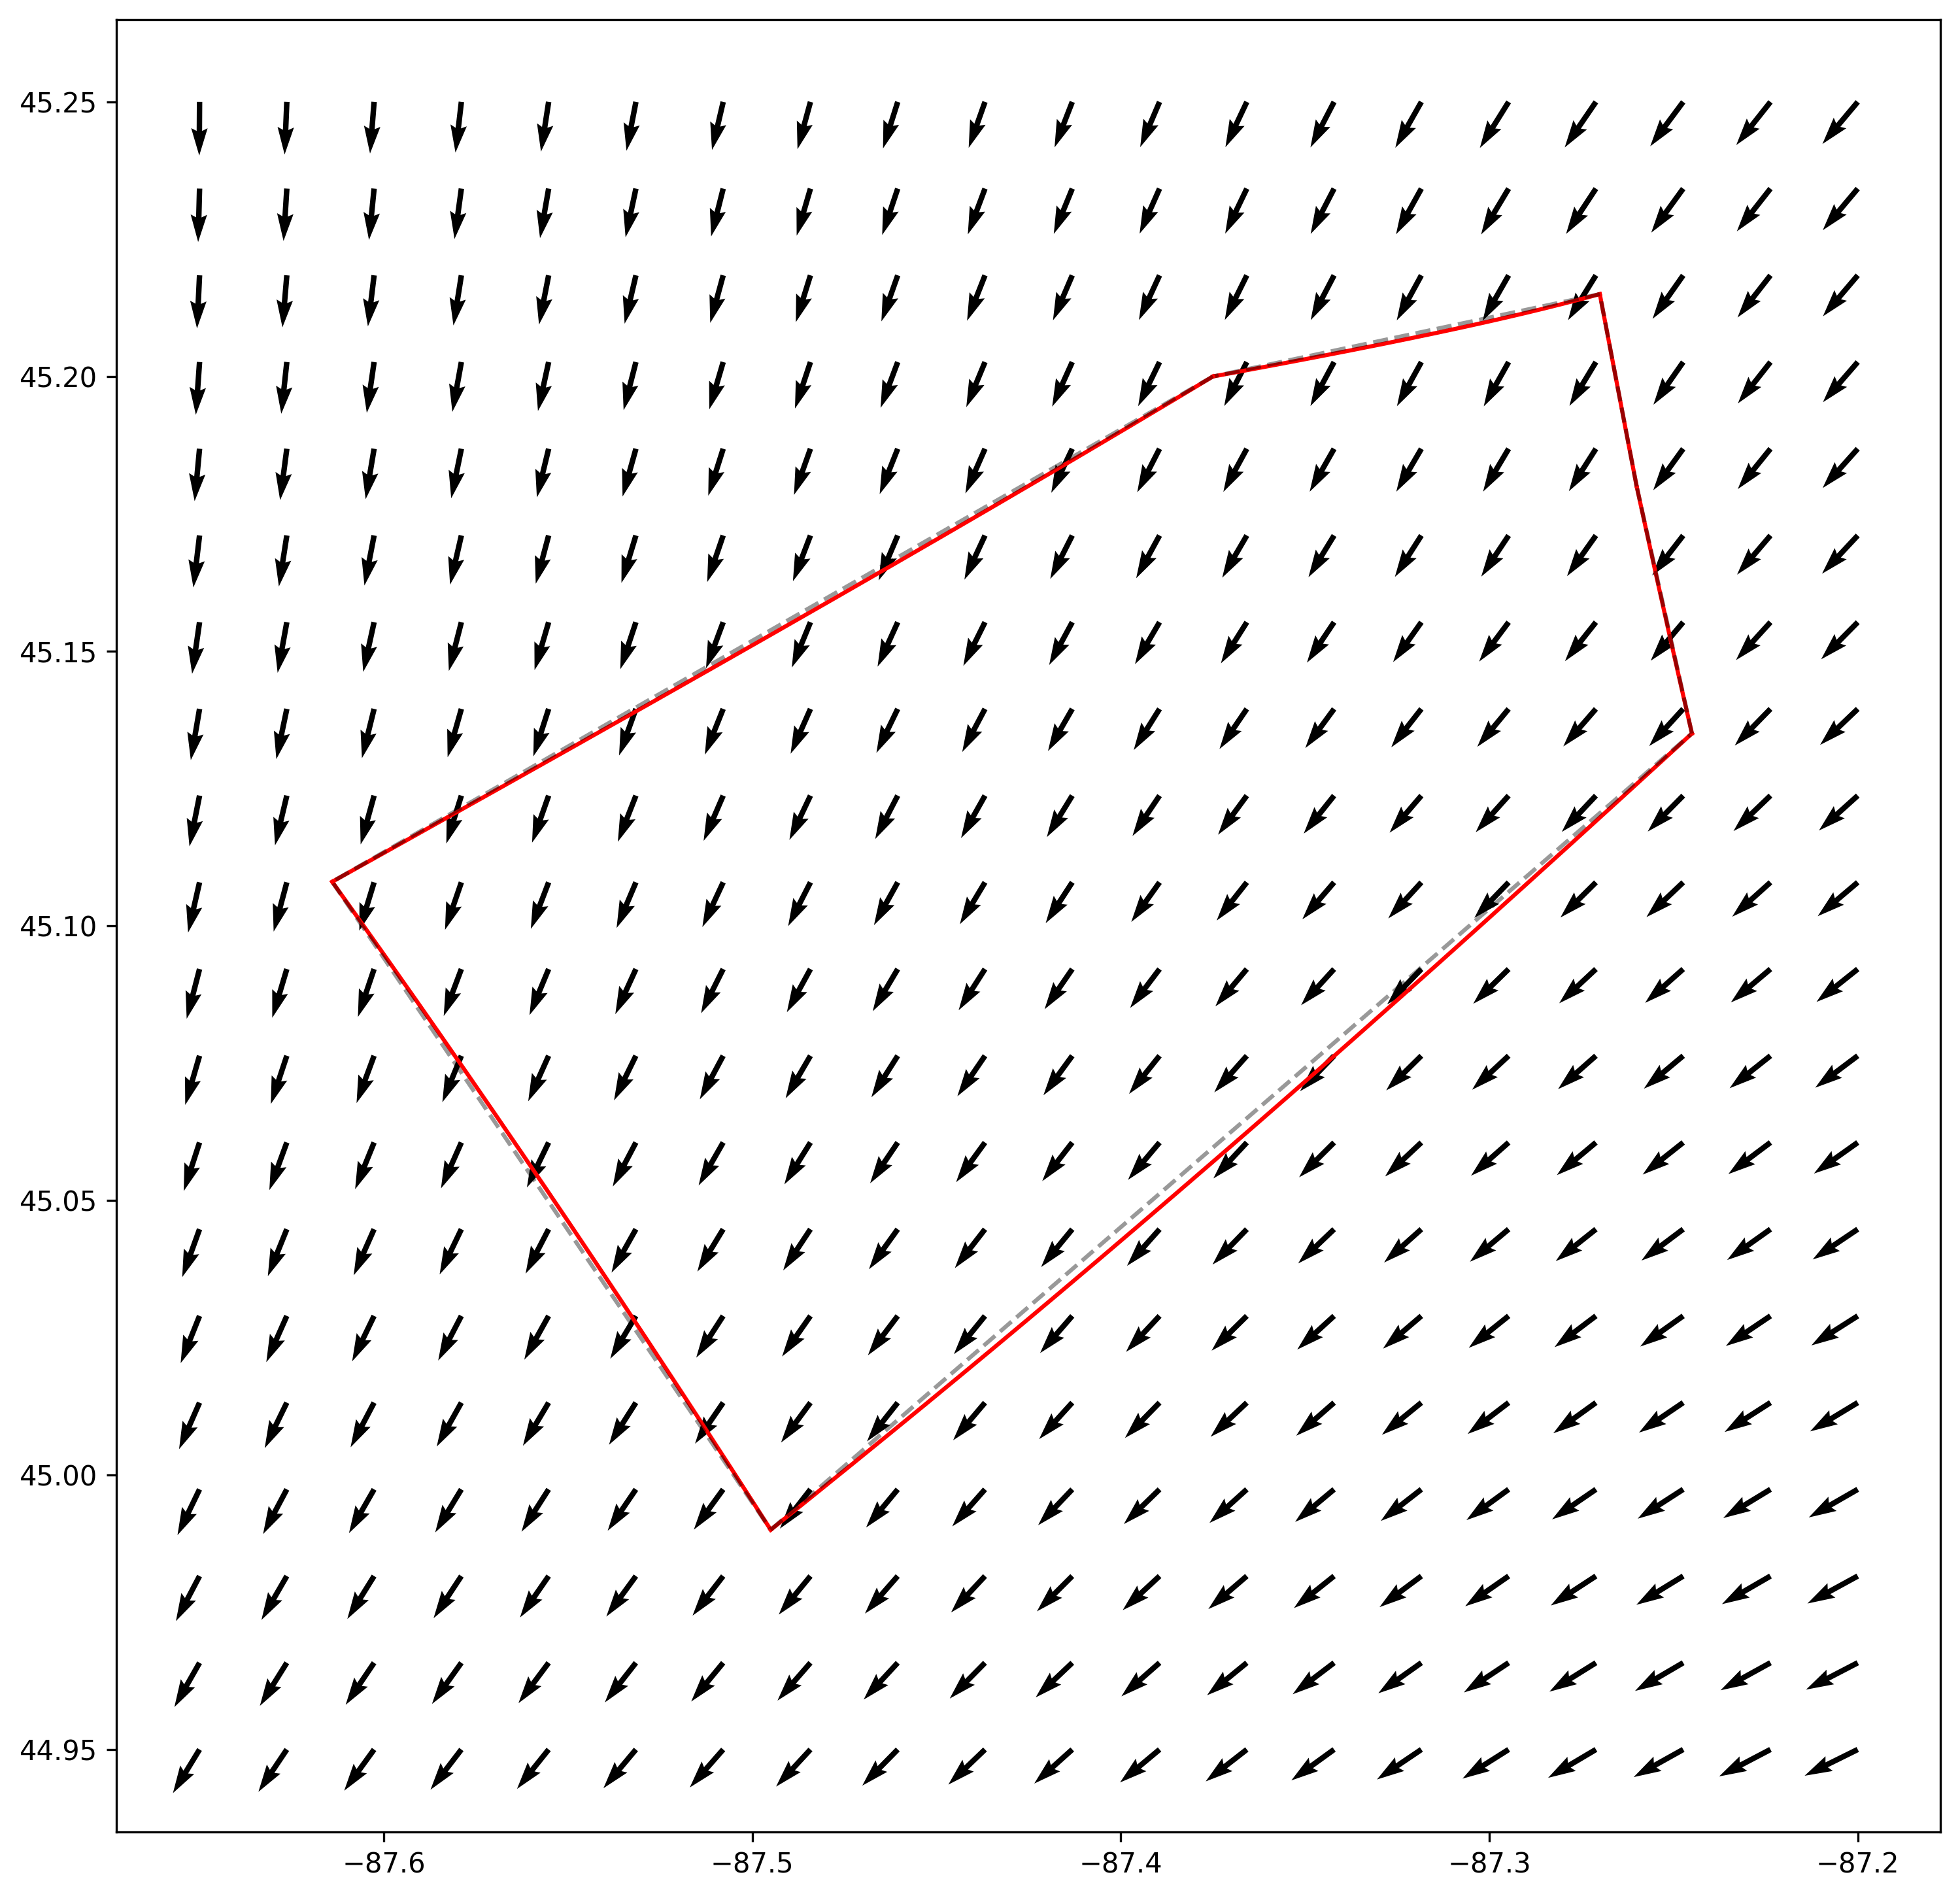

In [6]:
OFFICIAL = [
    (-87.614, 45.108),   # Start
    (-87.495, 44.990),   # Green Island
    (-87.245, 45.135),   # Fish Creek
    (-87.260, 45.180),   # Strawberry S
    (-87.270, 45.215),   # Strawberry N
    (-87.375, 45.200),   # Chambers Island
    (-87.614, 45.108),   # Finish
]

fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

for leg in range(6):
    x0, x1 = np.array(OFFICIAL[leg]), np.array(OFFICIAL[leg+1])
    sol = solve(x0, x1)

    ax.plot(sol.y[0], sol.y[1], 'r')
    ax.plot([x0[0], x1[0]], [x0[1], x1[1]], 'k--', alpha=.4)

X, Y = np.meshgrid(np.linspace(-87.65, -87.2, 20), np.linspace(44.95, 45.25, 20))
S = np.vstack([X.ravel(), Y.ravel()]).T
U, V = w(S)
U, V = U.reshape(X.shape), V.reshape(Y.shape)

ax.quiver(X, Y, U, V)

plt.show()

# On the Map

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy.interpolate import splprep, splev

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

In [8]:
# ── Race marks: (lon, lat) — NOTE: cartopy wants lon first ──────────────────
MARKS = {
    "Start/Finish\n(Menominee)": (-87.614, 45.108),
    "Green Island":              (-87.495, 44.990),
    "Fish Creek Buoy":           (-87.245, 45.135),
    "Strawberry Ch. S":          (-87.260, 45.180),
    "Strawberry Ch. N":          (-87.270, 45.215),
    "Chambers Island":           (-87.375, 45.200),
}

# Official course sequence (lon, lat)
OFFICIAL = [
    (-87.614, 45.108),   # Start
    (-87.495, 44.990),   # Green Island
    (-87.245, 45.135),   # Fish Creek
    (-87.260, 45.180),   # Strawberry S
    (-87.270, 45.215),   # Strawberry N
    (-87.375, 45.200),   # Chambers Island
    (-87.614, 45.108),   # Finish
]

# ── Islands / obstacles: (lon, lat, label, radius_deg_approx) ───────────────
OBSTACLES = [
    (-87.357, 45.184, "Chambers Island", 0.035)
    # (-87.370, 45.162, "Horseshoe\nIsland",    0.012),
    # (-87.268, 45.196, "Strawberry\nIslands",  0.018),
    # (-87.495, 44.990, "Green Island",         0.010),
    # (-87.340, 45.215, "Hat Island",           0.008),
    # (-87.290, 45.175, "Nicolet Bay\nShoals",  0.015),
]

# ── Map extent: [lon_min, lon_max, lat_min, lat_max] ────────────────────────
EXTENT = [-87.80, -87.10, 44.88, 45.35]

In [9]:
def smooth_route(waypoints, n=400):
    """Fit a cubic spline through (lon, lat) waypoints."""
    lons = np.array([p[0] for p in waypoints])
    lats = np.array([p[1] for p in waypoints])
    k = min(3, len(waypoints) - 1)
    tck, _ = splprep([lons, lats], s=0, k=k)
    u = np.linspace(0, 1, n)
    lons_s, lats_s = splev(u, tck)
    return list(zip(lons_s, lats_s))

In [10]:
PLATE = ccrs.PlateCarree()


def add_basemap_features(ax):
    """Add land, water, and coastline features to a cartopy axis."""
    ax.add_feature(cfeature.OCEAN.with_scale('10m'),      facecolor='#c8ddf0', zorder=0)
    ax.add_feature(cfeature.LAND.with_scale('10m'),       facecolor='#e8e4d9', zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale('10m'),      facecolor='#c8ddf0', zorder=1)
    ax.add_feature(cfeature.RIVERS.with_scale('10m'),     edgecolor='#a0bcd0', linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'),  edgecolor='#6a8fa8', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'),    edgecolor='#aaaaaa', linewidth=0.5, linestyle=':', zorder=3)
    ax.add_feature(cfeature.STATES.with_scale('10m'),     edgecolor='#bbbbbb', linewidth=0.4, linestyle='--', zorder=3)


def draw_course(ax, waypoints, color='#222222', lw=1.6,
                linestyle='--', label='Official course', zorder=5):
    lons = [p[0] for p in waypoints]
    lats = [p[1] for p in waypoints]
    ax.plot(lons, lats, linestyle=linestyle, color=color,
            linewidth=lw, transform=PLATE, zorder=zorder, label=label)


def draw_route(ax, route, color, label, lw=2.2, zorder=6):
    lons = [p[0] for p in route]
    lats = [p[1] for p in route]
    ax.plot(lons, lats, color=color, linewidth=lw,
            transform=PLATE, zorder=zorder, label=label, alpha=0.88)
    # Direction arrow at ~60% along the route
    mid = int(len(route) * 0.6)
    ax.annotate('', xy=(lons[mid+3], lats[mid+3]),
                xytext=(lons[mid], lats[mid]),
                xycoords=PLATE._as_mpl_transform(ax),
                textcoords=PLATE._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8),
                zorder=zorder+1)


def draw_marks(ax, marks, zorder=10):
    for i, (name, (lon, lat)) in enumerate(marks.items(), start=1):
        is_start = i == 1
        color = '#111111' if is_start else '#cc2200'
        marker = 's' if is_start else 'o'
        ax.plot(lon, lat, marker=marker, color=color, markersize=9 if is_start else 8,
                markeredgecolor='white', markeredgewidth=1.2,
                transform=PLATE, zorder=zorder)
        # Number badge
        ax.text(lon, lat, str(i), color='white', fontsize=5.5, fontweight='bold',
                ha='center', va='center', transform=PLATE, zorder=zorder+1)
        # Label — nudge to avoid overlap
        nudge = {1: (0.010, 0.006), 2: (-0.015, -0.012),
                 3: (0.010, 0.006), 4: (0.012, -0.005),
                 5: (0.012, 0.005), 6: (-0.005, 0.010)}
        dx, dy = nudge.get(i, (0.008, 0.006))
        ax.text(lon + dx, lat + dy, name,
                fontsize=6.5, color='#111111', transform=PLATE,
                zorder=zorder+1, ha='left',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])


def draw_obstacles(ax, obstacles, zorder=4):
    for lon, lat, label, r in obstacles:
        # Filled circle for island body
        circ = mpatches.Ellipse((lon, lat), width=r*1.4, height=r,
                                 facecolor='#c8b89a', edgecolor='#8a6a40',
                                 linewidth=1.0, transform=PLATE, zorder=zorder,
                                 alpha=0.85)
        ax.add_patch(circ)
        # Dashed exclusion ring
        ring = mpatches.Ellipse((lon, lat), width=(r+0.008)*1.4, height=r+0.008,
                                 facecolor='none', edgecolor='#e6550d',
                                 linewidth=0.8, linestyle=':', transform=PLATE,
                                 zorder=zorder+1, alpha=0.7)
        ax.add_patch(ring)
        ax.text(lon, lat - r - 0.006, label, fontsize=5.5,
                color='#7f2704', ha='center', transform=PLATE, zorder=zorder+2,
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])


def add_legend(ax, extra_handles=None):
    handles = [
        Line2D([0],[0], color='#222', lw=1.6, linestyle='--', label='Official course'),
        mpatches.Patch(facecolor='#c8b89a', edgecolor='#8a6a40', label='Island / shoal'),
        mpatches.Patch(facecolor='none', edgecolor='#e6550d',
                       linestyle=':', label='Exclusion zone'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#cc2200',
               markeredgecolor='white', markersize=8, label='Race mark'),
        Line2D([0],[0], marker='s', color='w', markerfacecolor='#111',
               markeredgecolor='white', markersize=8, label='Start / Finish'),
    ]
    if extra_handles:
        handles += extra_handles
    ax.legend(handles=handles, loc='lower right', fontsize=6.5,
              framealpha=0.92, edgecolor='#cccccc', fancybox=False)


def add_scalebar(ax, lon0, lat0, length_nm=10):
    """Rough scale bar — 1 nm ≈ 1/60 degree latitude."""
    deg = length_nm / 60.0
    ax.plot([lon0, lon0 + deg], [lat0, lat0], 'k-', lw=3, transform=PLATE, zorder=20)
    ax.text(lon0 + deg/2, lat0 + 0.004, f'{length_nm} nm',
            ha='center', fontsize=6, transform=PLATE, zorder=20)

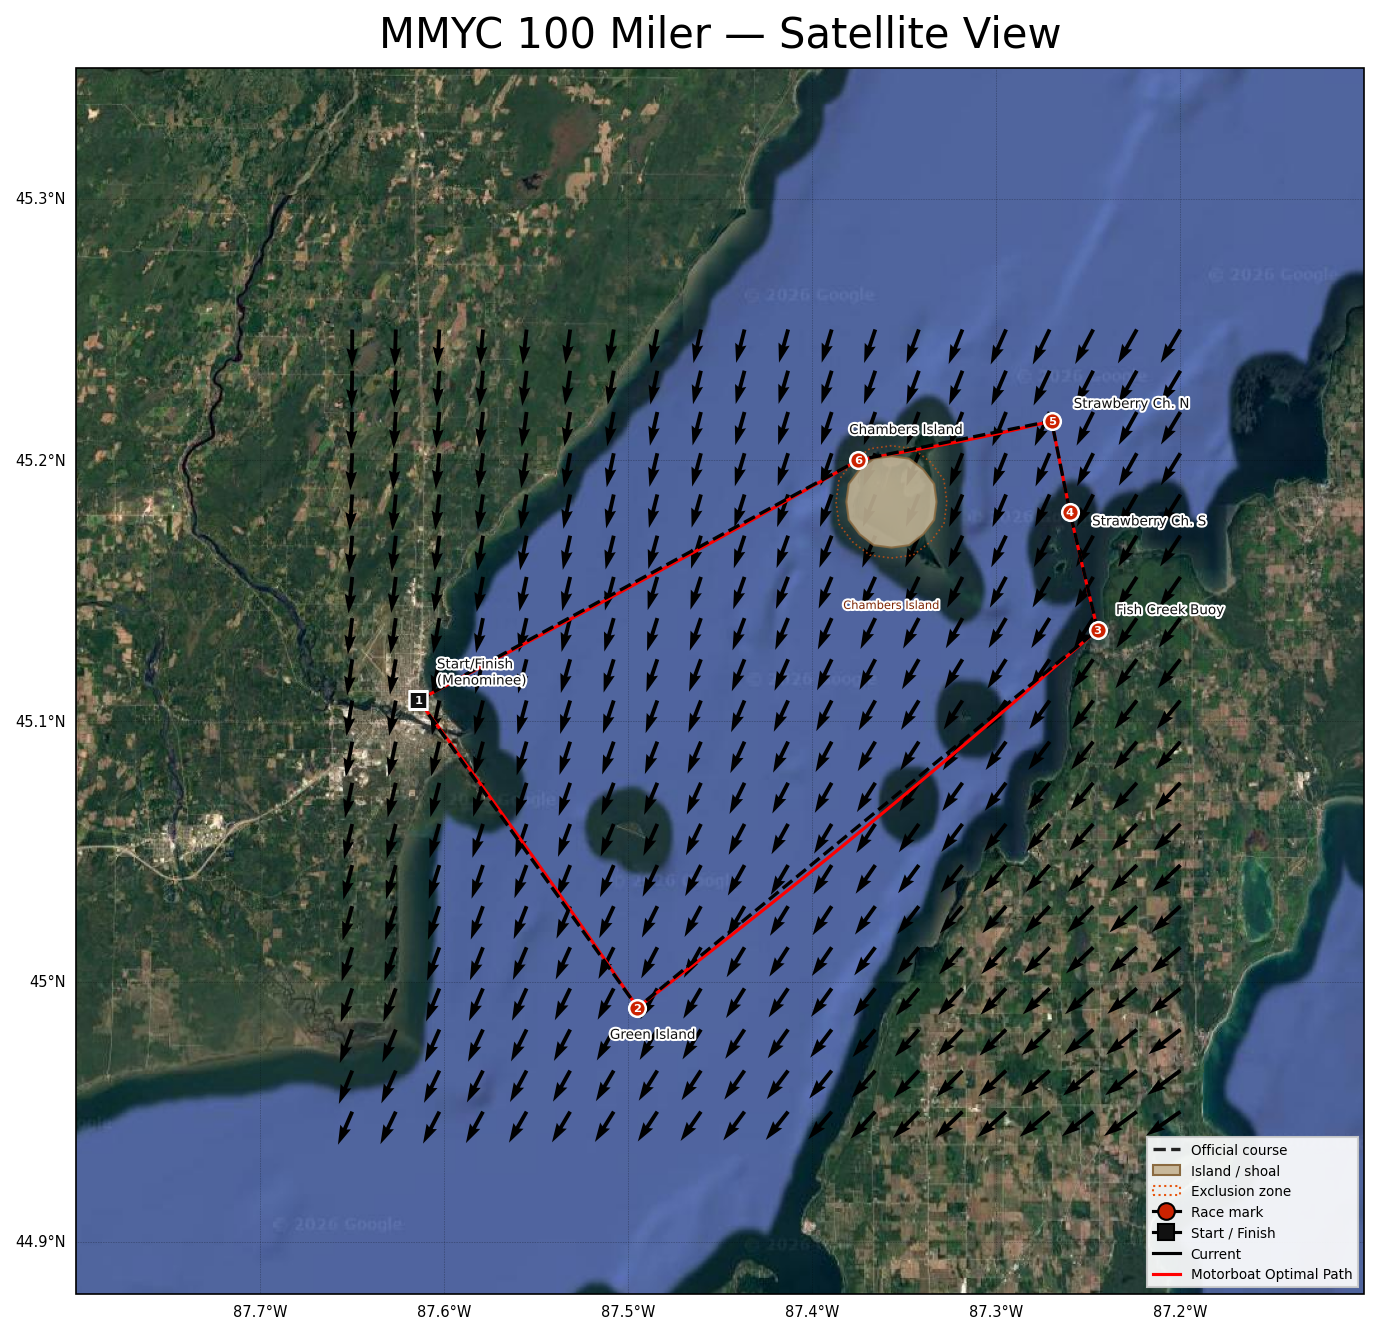

In [ ]:
# Stamen Terrain gives a nice topographic feel for coastal sailing maps
tiler = cimgt.GoogleTiles(style='satellite')   # swap to 'terrain' or 'street' if preferred

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(1, 1, 1, projection=tiler.crs)

ax.set_extent(EXTENT, crs=PLATE)
ax.add_image(tiler, 11)   # zoom level 11 — increase for more detail, slower fetch

draw_obstacles(ax, OBSTACLES)
draw_course(ax, OFFICIAL, color='black', label='Official course')
draw_marks(ax, MARKS)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='#00000088',
                  linestyle=':', x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'black'}
gl.ylabel_style = {'size': 7, 'color': 'black'}


for leg in range(6):
    x0, x1 = np.array(OFFICIAL[leg]), np.array(OFFICIAL[leg+1])
    sol = solve(x0, x1)

    ax.plot(sol.y[0], sol.y[1], 'r', transform=PLATE)

X, Y = np.meshgrid(np.linspace(-87.65, -87.2, 20),
                   np.linspace(44.95, 45.25, 20))
S = np.vstack([X.ravel(), Y.ravel()]).T
U, V = w(S)
U, V = U.reshape(X.shape), V.reshape(Y.shape)

ax.quiver(X, Y, U, V, transform=PLATE, label="Current")

# Making the legend
handles = [
    Line2D([0],[0], color='#222', lw=1.6, linestyle='--', label='Official course'),
    mpatches.Patch(facecolor='#c8b89a', edgecolor='#8a6a40', label='Island / shoal'),
    mpatches.Patch(facecolor='none', edgecolor='#e6550d',
                linestyle=':', label='Exclusion zone'),
    Line2D([0],[0], marker='o', color='k', markerfacecolor='#cc2200',
        markeredgecolor='black', markersize=8, label='Race mark'),
    Line2D([0],[0], marker='s', color='k', markerfacecolor='#111',
        markeredgecolor='black', markersize=8, label='Start / Finish'),
    Line2D([0],[0], color='k', markerfacecolor='#111',
        markeredgecolor='black', markersize=8, label='Current'),
        Line2D([0],[0], color='red', markerfacecolor='#111',
        markeredgecolor='black', markersize=8, label='Motorboat Optimal Path'),
]
ax.legend(handles=handles, loc='lower right', fontsize=6.5,
        framealpha=0.92, edgecolor='#cccccc', fancybox=False)

ax.set_title('MMYC 100 Miler — Two Optimal Paths', fontsize=20, pad=10, color='black')
fig.patch.set_facecolor('white')

plt.tight_layout()
# plt.savefig('mmyc_100_miler_satellite.png', dpi=200, bbox_inches='tight')
plt.show()